
--- Running MCMC ---
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'sigma_beta_intrinsic']


100%|██████████| 1000/1000 [03:16<00:00,  5.10it/s]


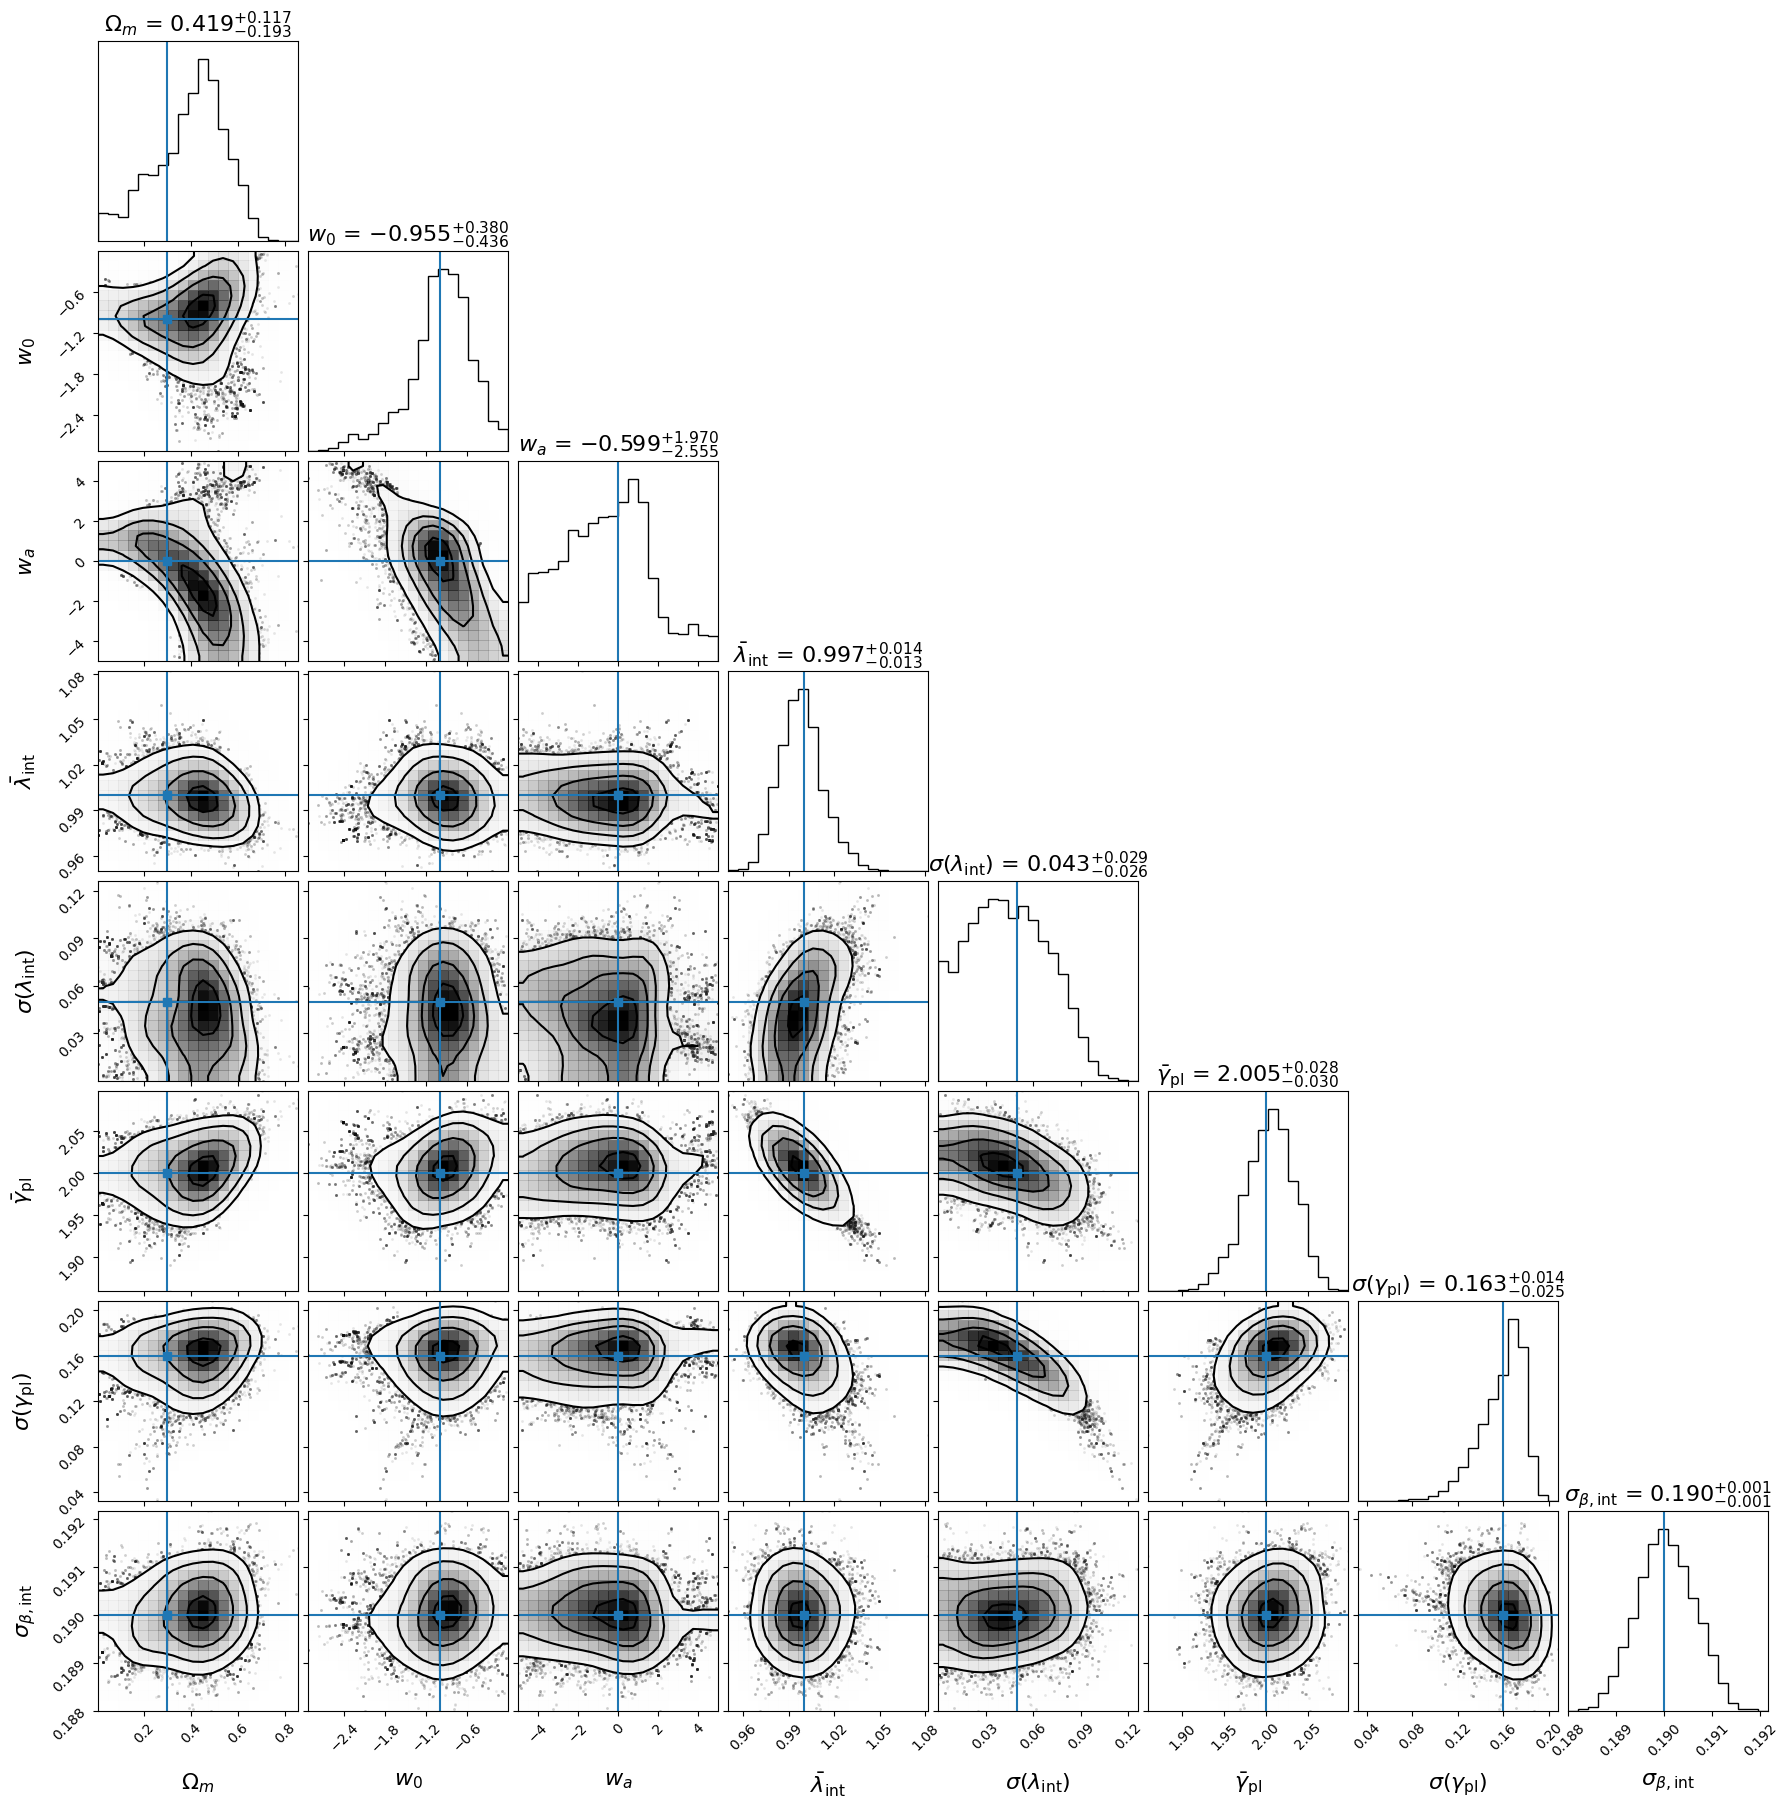

In [14]:
import numpy as np
from astropy.cosmology import Flatw0waCDM
from dspl_inference_all_scatters import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt

# 1. SETUP COMPREHENSIVE TRUTH
truth = {
    'h0': 70.0, 
    'om': 0.3, 
    'w0': -1.0, 
    'wa': 0.0,
    'lambda_int': 1.0, 
    'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 
    'gamma_sigma': 0.16,
    'sigma_beta_intrinsic': 0.19
}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# 2. GENERATE MOCK ASIMOV DATA
kwargs_list = []
num_lenses = 1000
down_sampling = 86

for _ in range(num_lenses):
    z_lens = np.random.normal(loc=0.5, scale=0.1)
    z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)
    z2 = np.random.uniform(low=z1 + 0.1, high=3.0)
    
    sigma_beta_meas, sigma_beta_los = 0.01, 0.01
    sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
    
    kwargs_list.append(draw_lens_from_given_zs(
        z_lens=z_lens, z1=z1, z2=z2,
        lambda_mst_mean=truth['lambda_int'], 
        lambda_mst_sigma=truth['lambda_sigma'],
        gamma_pl_mean=truth['gamma_pl'], 
        gamma_pl_sigma=truth['gamma_sigma'],
        sigma_beta_intrinsic=truth['sigma_beta_intrinsic'], 
        sigma_meas_rel=sigma_meas_rel, 
        down_sampling=down_sampling, 
        with_noise=False, 
        cosmo=cosmo_true,
        redshift_error_rel=0.03
    ))

# 3. CONFIGURE MCMC INFERENCE
# We fix H0 as this does not impact PDSPLs
fixed_params = {'h0': 70.0}

my_guess = {
    'om': 0.3, 
    'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16,
    'sigma_beta_intrinsic': 0.19
}

my_spreads = {
    'om': 0.05, 
    'w0': 0.05, 'wa': 0.05,
    'lambda_int': 0.05, 'lambda_sigma': 0.02,
    'gamma_pl': 0.05, 'gamma_sigma': 0.02,
    'sigma_beta_intrinsic': 0.01
}

my_priors = {
            'h0': ('uniform', 50.0, 90.0),
            'om': ('uniform', 0.0, 1.0),
            'w0': ('uniform', -3.0, 0.0),
            'wa': ('uniform', -5.0, 5.0),
            'lambda_int': ('uniform', 0.8, 1.2),
            'lambda_sigma': ('uniform', 0.0, 0.2),
            'gamma_pl': ('uniform', 1.0, 3.0),
            'gamma_sigma': ('uniform', 0.0, 0.5),
            'sigma_beta_intrinsic': ('uniform', 0.0, 0.5)
        }

# 4. RUN INFERENCE
print("\n--- Running MCMC ---")
samples, labels = run_dspl_inference(
    kwargs_list,
    down_sampling=down_sampling,
    n_walkers=64, n_steps=1000, n_burn=500,
    initial_guess=my_guess, 
    initial_scatter=my_spreads,
    fixed_params=fixed_params,
    priors = my_priors
)

# 5. PLOT CORNER
# Truths perfectly map to the 8 sampled parameters
full_truths_list = [
    truth['om'], 
    truth['w0'], 
    truth['wa'], 
    truth['lambda_int'], 
    truth['lambda_sigma'],
    truth['gamma_pl'], 
    truth['gamma_sigma'],
    truth['sigma_beta_intrinsic']
]

fig = corner.corner(
    samples, 
    labels=labels, 
    truths=full_truths_list,
    truth_color="#1f77b4",
    smooth=1.5,
    show_titles=True,
    title_fmt=".3f", 
    title_kwargs={"fontsize": 16},  
    label_kwargs={"fontsize": 16} 
)

plt.show()


--- Running MCMC ---
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'sigma_beta_intrinsic']


100%|██████████| 1000/1000 [03:24<00:00,  4.88it/s]


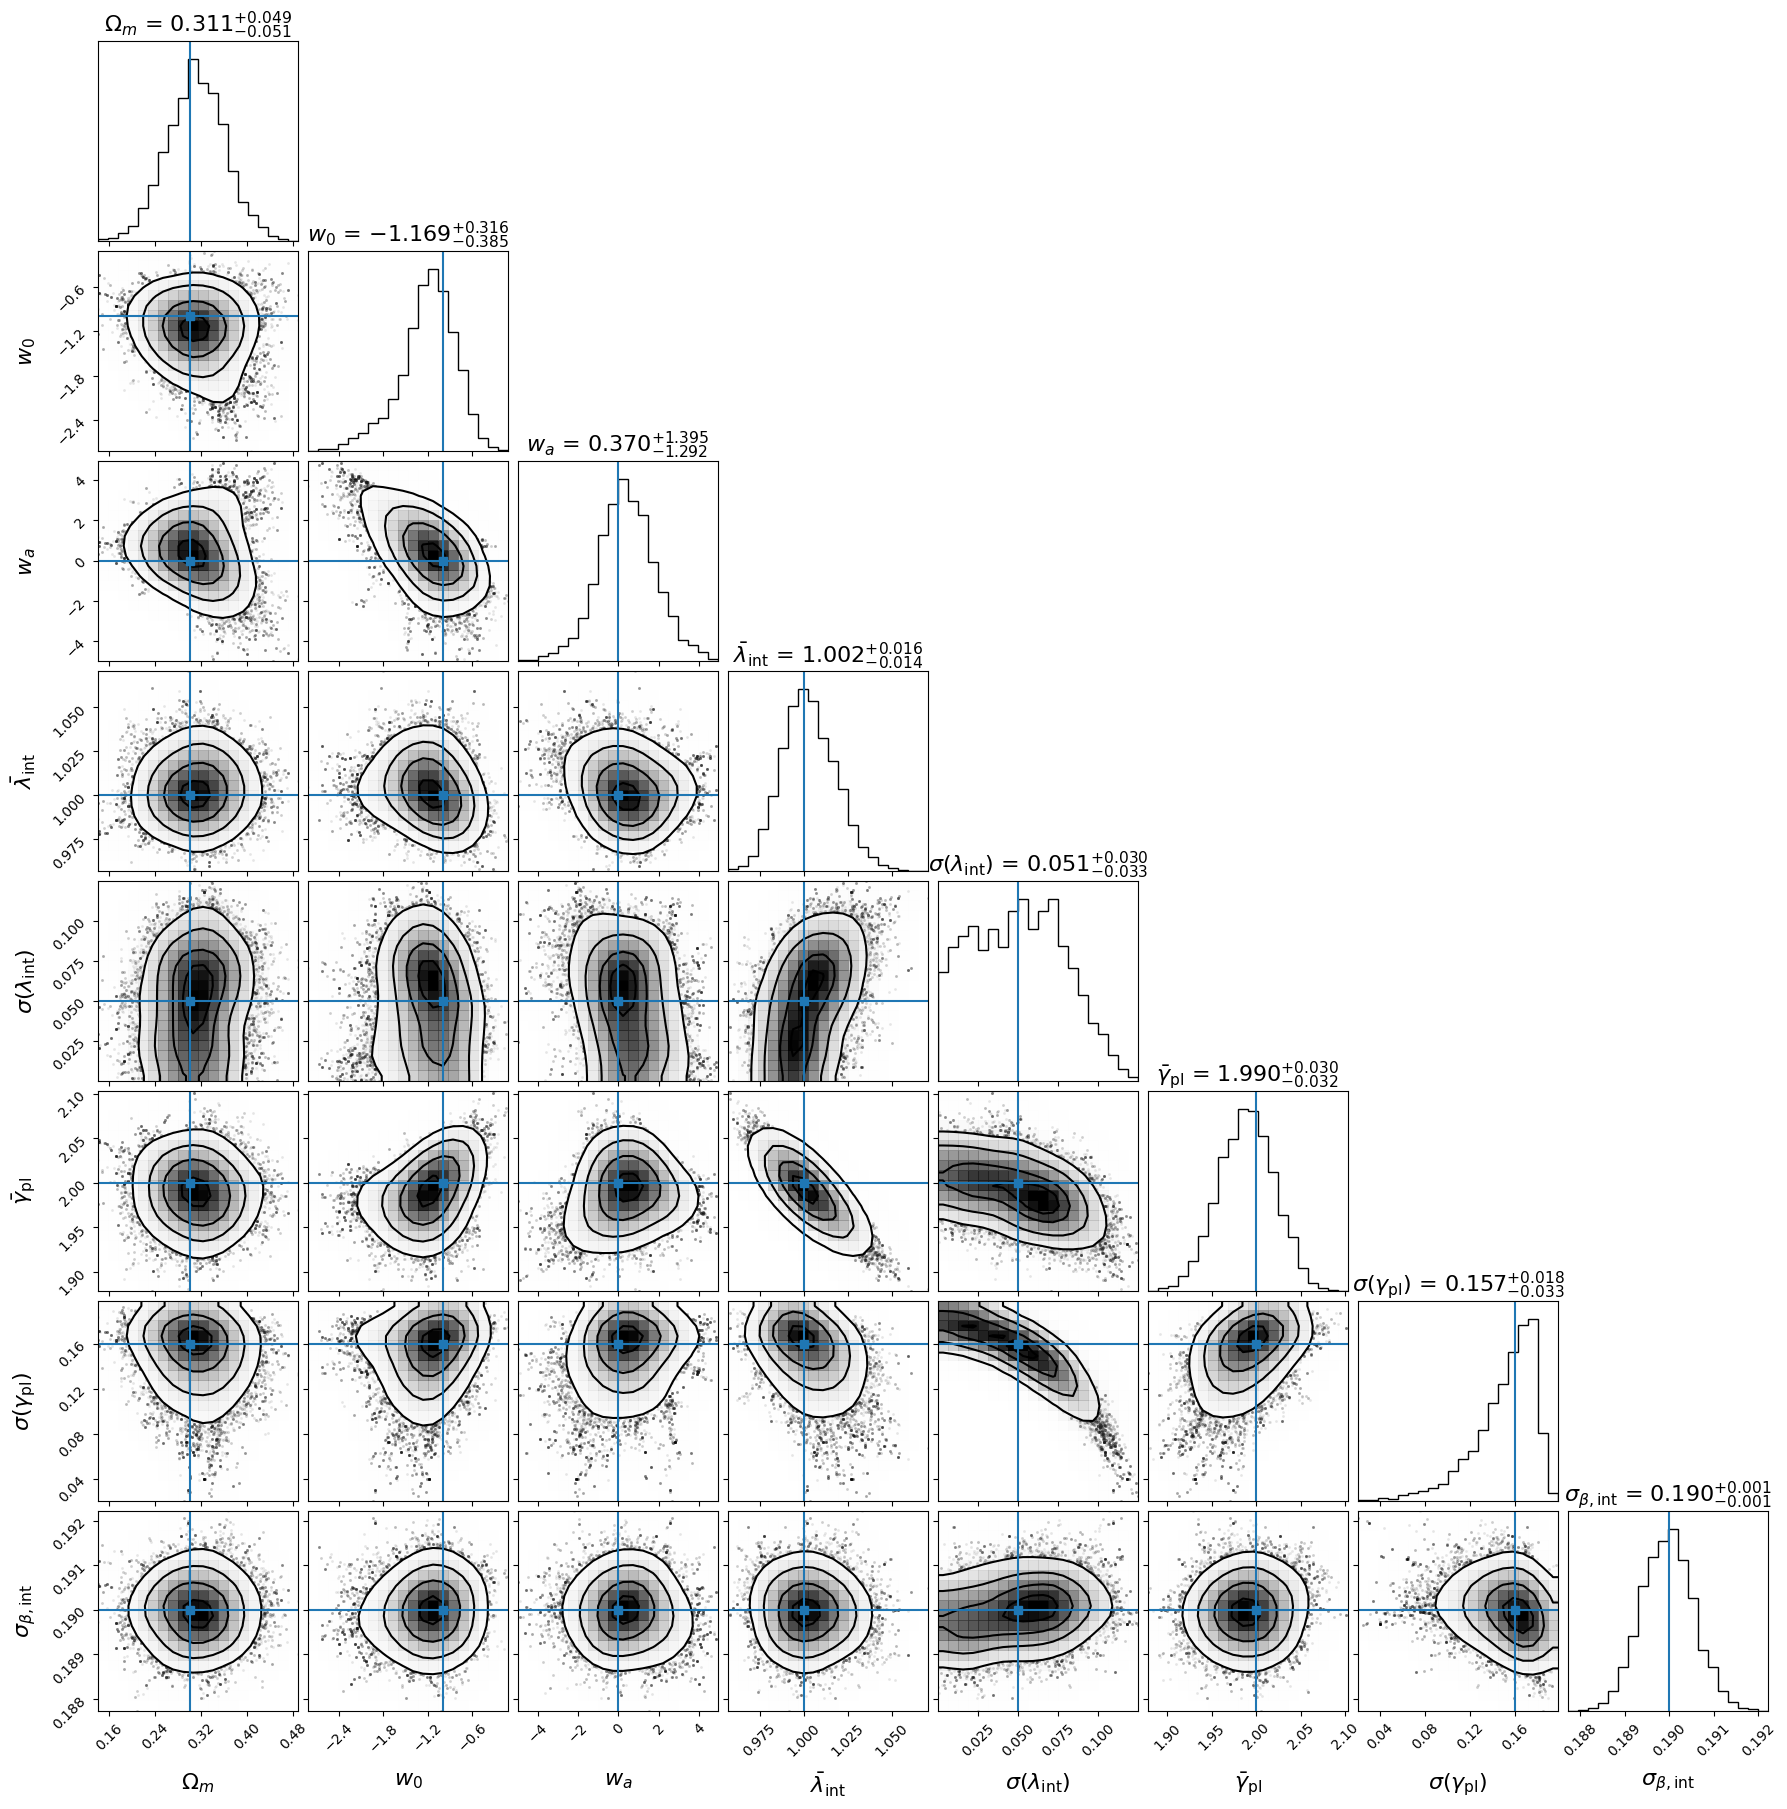

In [15]:
import numpy as np
from astropy.cosmology import Flatw0waCDM
from dspl_inference_all_scatters import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt

# 1. SETUP COMPREHENSIVE TRUTH
truth = {
    'h0': 70.0, 
    'om': 0.3, 
    'w0': -1.0, 
    'wa': 0.0,
    'lambda_int': 1.0, 
    'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 
    'gamma_sigma': 0.16,
    'sigma_beta_intrinsic': 0.19
}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# 2. GENERATE MOCK ASIMOV DATA
kwargs_list = []
num_lenses = 1000
down_sampling = 86

for _ in range(num_lenses):
    z_lens = np.random.normal(loc=0.5, scale=0.1)
    z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)
    z2 = np.random.uniform(low=z1 + 0.1, high=3.0)
    
    sigma_beta_meas, sigma_beta_los = 0.01, 0.01
    sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
    
    kwargs_list.append(draw_lens_from_given_zs(
        z_lens=z_lens, z1=z1, z2=z2,
        lambda_mst_mean=truth['lambda_int'], 
        lambda_mst_sigma=truth['lambda_sigma'],
        gamma_pl_mean=truth['gamma_pl'], 
        gamma_pl_sigma=truth['gamma_sigma'],
        sigma_beta_intrinsic=truth['sigma_beta_intrinsic'], 
        sigma_meas_rel=sigma_meas_rel, 
        down_sampling=down_sampling, 
        with_noise=False, 
        cosmo=cosmo_true,
        redshift_error_rel=0.03
    ))

# 3. CONFIGURE MCMC INFERENCE
# We fix H0 as this does not impact PDSPLs
fixed_params = {'h0': 70.0}

my_guess = {
    'om': 0.3, 
    'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16,
    'sigma_beta_intrinsic': 0.19
}

my_spreads = {
    'om': 0.05, 
    'w0': 0.05, 'wa': 0.05,
    'lambda_int': 0.05, 'lambda_sigma': 0.02,
    'gamma_pl': 0.05, 'gamma_sigma': 0.02,
    'sigma_beta_intrinsic': 0.01
}

my_priors = {
            'h0': ('uniform', 50.0, 90.0),
            'om': ('gaussian', 0.3, 0.05),
            'w0': ('uniform', -3.0, 0.0),
            'wa': ('uniform', -5.0, 5.0),
            'lambda_int': ('uniform', 0.8, 1.2),
            'lambda_sigma': ('uniform', 0.0, 0.2),
            'gamma_pl': ('uniform', 1.0, 3.0),
            'gamma_sigma': ('uniform', 0.0, 0.5),
            'sigma_beta_intrinsic': ('uniform', 0.0, 0.5)
        }

# 4. RUN INFERENCE
print("\n--- Running MCMC ---")
samples, labels = run_dspl_inference(
    kwargs_list,
    down_sampling=down_sampling,
    n_walkers=64, n_steps=1000, n_burn=500,
    initial_guess=my_guess, 
    initial_scatter=my_spreads,
    fixed_params=fixed_params,
    priors = my_priors
)

# 5. PLOT CORNER
# Truths perfectly map to the 8 sampled parameters
full_truths_list = [
    truth['om'], 
    truth['w0'], 
    truth['wa'], 
    truth['lambda_int'], 
    truth['lambda_sigma'],
    truth['gamma_pl'], 
    truth['gamma_sigma'],
    truth['sigma_beta_intrinsic']
]

fig = corner.corner(
    samples, 
    labels=labels, 
    truths=full_truths_list,
    truth_color="#1f77b4",
    smooth=1.5,
    show_titles=True,
    title_fmt=".3f", 
    title_kwargs={"fontsize": 16},  
    label_kwargs={"fontsize": 16} 
)

plt.show()

## Actual LSST Y10 sample

Loading PDSPL samples...

Scenario: LSST Y10
Total True Lenses: 85889
Simulated Lenses : 2000
Down-Sampling f  : 42.94
Generated 2000 mock lenses.

--- Running MCMC ---
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'sigma_beta_intrinsic']


100%|██████████| 1000/1000 [05:04<00:00,  3.28it/s]


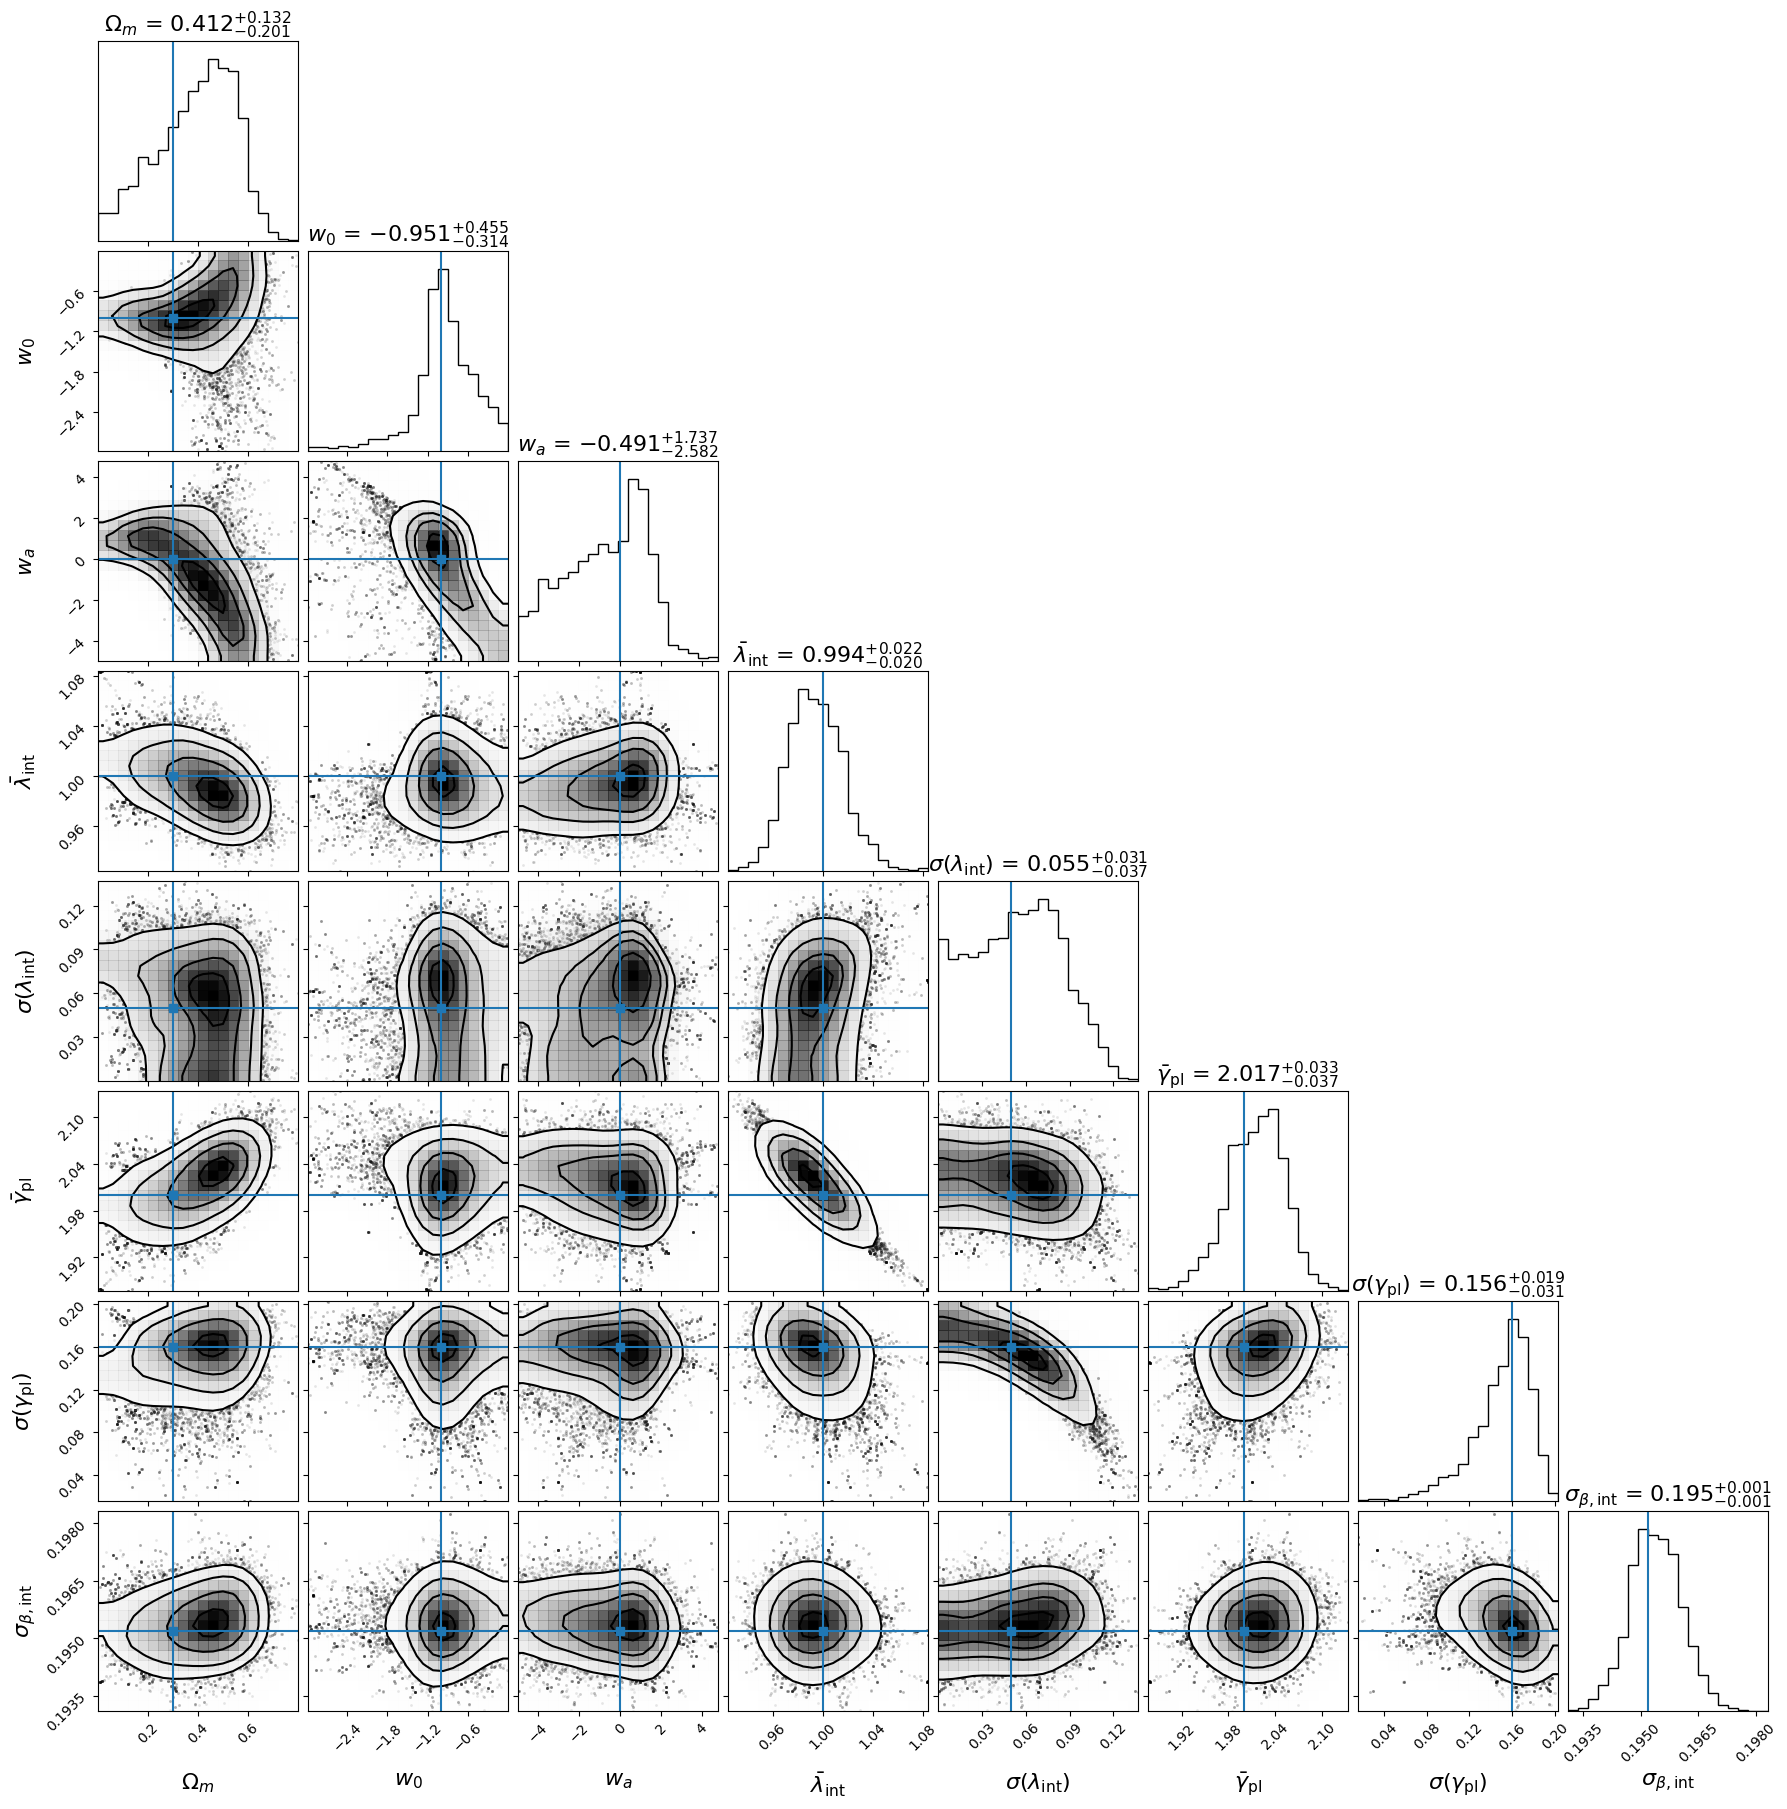

In [5]:
import pickle
import numpy as np
from astropy.cosmology import Flatw0waCDM
from dspl_inference_all_scatters import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION & TRUTH ---
truth = {
    'h0': 70.0, 
    'om': 0.3, 
    'w0': -1.0, 
    'wa': 0.0,
    'lambda_int': 1.0, 
    'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 
    'gamma_sigma': 0.16,
}
fixed_params = {'h0': 70.0}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# --- 2. PREPARE THE LSST Y10 DATASET ---
print("Loading PDSPL samples...")
with open('../../data/samples/pdspl_samples_with_pairs.pkl', 'rb') as f:
    pdspl_samples = pickle.load(f)

# Extract only the LSST Y10 scenario
key = 'lsst_y10'
y10_data = pdspl_samples[key]

# Setup scenario parameters
pairs_table = y10_data['pairs_analysis']['pairs_table']
pairs_table_with_errors = y10_data['pairs_analysis']['pairs_table_with_errors']
coeffs = y10_data['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs']
total_lenses = len(pairs_table)

median_injected_intrinsic = np.std(pairs_table_with_errors['rel_diff_beta_E'])
truth['sigma_beta_intrinsic'] = median_injected_intrinsic

# We want to simulate the full Y10 yield, but limit actual generated points to save compute
# Downsample to at most 2000 lenses for the MCMC likelihood evaluation
num_samples = min(2000, total_lenses)
down_sampling = total_lenses / num_samples

print(f"\nScenario: LSST Y10")
print(f"Total True Lenses: {total_lenses}")
print(f"Simulated Lenses : {num_samples}")
print(f"Down-Sampling f  : {down_sampling:.2f}")

# --- 3. GENERATE MOCK ASIMOV DATA ---
kwargs_list = []
random_indices = np.random.choice(len(pairs_table), size=num_samples, replace=False)

for i in random_indices:
    z_lens = pairs_table["z_D"][i]
    z1 = pairs_table["z_S1"][i]
    z2 = pairs_table["z_S2"][i]
    
    # Calculate known observational/LOS uncertainties separately
    sigma_beta_meas, sigma_beta_los = 0.01, 0.01
    sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
    
    # In your old code, the dissimilarity fit WAS the intrinsic beta scatter.
    # We will use it here to define the true 'sigma_beta_intrinsic' for each specific lens.
    # dissimilarity = pairs_table_with_errors['dissimilarity'][i]
    # true_lens_intrinsic_scatter = np.polyval(coeffs, dissimilarity)
    true_lens_intrinsic_scatter = truth['sigma_beta_intrinsic']
    
    kwargs_list.append(draw_lens_from_given_zs(
        z_lens=z_lens, z1=z1, z2=z2,
        lambda_mst_mean=truth['lambda_int'], 
        lambda_mst_sigma=truth['lambda_sigma'],
        gamma_pl_mean=truth['gamma_pl'], 
        gamma_pl_sigma=truth['gamma_sigma'],
        # Inject the realistic, dissimilarity-derived intrinsic scatter
        sigma_beta_intrinsic=true_lens_intrinsic_scatter, 
        sigma_meas_rel=sigma_meas_rel, 
        down_sampling=down_sampling, 
        with_noise=False, # True for Noisy, False for Asimov
        cosmo=cosmo_true,
        redshift_error_rel=0.03 # 3% photo-z error for LSST
    ))

print(f"Generated {len(kwargs_list)} mock lenses.")

# --- 4. CONFIGURE MCMC INFERENCE ---
my_guess = {
    'om': 0.3, 
    'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16,
    'sigma_beta_intrinsic': 0.19
}

my_spreads = {
    'om': 0.05, 
    'w0': 0.05, 'wa': 0.05,
    'lambda_int': 0.05, 'lambda_sigma': 0.02,
    'gamma_pl': 0.05, 'gamma_sigma': 0.02,
    'sigma_beta_intrinsic': 0.01
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5),
    'sigma_beta_intrinsic': ('uniform', 0.0, 0.5)
}

# --- 5. RUN INFERENCE ---
print("\n--- Running MCMC ---")
samples, labels = run_dspl_inference(
    kwargs_list,
    down_sampling=down_sampling,
    n_walkers=64, 
    n_steps=1000, 
    n_burn=500,
    initial_guess=my_guess, 
    initial_scatter=my_spreads,
    fixed_params=fixed_params,
    priors=my_priors
)

# --- 6. PLOT CORNER ---

full_truths_list = [
    truth['om'], 
    truth['w0'], 
    truth['wa'], 
    truth['lambda_int'], 
    truth['lambda_sigma'],
    truth['gamma_pl'], 
    truth['gamma_sigma'],
    median_injected_intrinsic
]

fig = corner.corner(
    samples, 
    labels=labels, 
    truths=full_truths_list,
    truth_color="#1f77b4",
    smooth=1.5,
    show_titles=True,
    title_fmt=".3f", 
    title_kwargs={"fontsize": 16},  
    label_kwargs={"fontsize": 16} 
)

plt.show()